In [1]:
import torch
from model.model import EncoderDecoderDAG
from utils.data import TranslateDatasetMultiple, collate_fn, process_data
from torch.utils.data import DataLoader
from utils.load_tokenizer import load_tokenizer
from torch.optim import Adam
from typing import Tuple
from torch.utils.tensorboard import SummaryWriter
from losses.dag_loss import dag_loss
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from utils.checkpoint import try_loading, epoch_resume, save_checkpoint

g:\Projects\Visual Studio Code\LMTests\lmtest\lib\site-packages\transformers\utils\hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
tokenizer, vocab_size = load_tokenizer()

In [3]:
data_dir = "data"
data_files = ["processed.pt", "processed2.pt", "processed3.pt"]

In [4]:
ds = TranslateDatasetMultiple(data_dir, data_files)

Loading data from data\processed.pt
Loading data from data\processed2.pt
Loading data from data\processed3.pt


In [5]:
batch_size = 8

In [6]:
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

In [7]:
# sample = next(iter(dl))

In [8]:
# ens, zhs = sample

In [9]:
pad_idx = tokenizer.pad_token_id

In [10]:
factor = 4
emb_size = 512
num_heads = 16
max_seq_len = 100
max_vertices = max_seq_len * factor
phm_factor = -1 # -1 for no phm, using standard linear layer
lm_head_factor = -1 # same as above

In [11]:
layers = [(2,2), 1, (1,1)]
out_layers = 2

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
device

device(type='cuda')

In [14]:
def create_model_fallback_fn() -> Tuple[EncoderDecoderDAG, Adam]:
    model = EncoderDecoderDAG(
        vocab_size, 
        emb_size, 
        num_heads, 
        max_seq_len, 
        max_vertices, 
        layers, 
        out_layers,
        phm_factor=phm_factor,
        lm_head_factor=lm_head_factor
    )
    model.to(device)
    optm = Adam(model.parameters(), lr=1e-3)
    return model, optm
    

In [15]:
checkpoint_dir = "./checkpoints"
checkpoint_name = "naivedag.pt"

In [16]:
model_class = EncoderDecoderDAG
optm_class = Adam

In [17]:
model, optm, losses, log_dir, tokens_seen = try_loading(checkpoint_dir, checkpoint_name, model_class, optm_class, device, create_model_fallback_fn)

Resuming, have seen 1,260,993 epochs and 445,217,548 tokens
Have 102093818 trainable parameters
Logging to runs/run_at_2023-12-29_15-32-10_new_loss


In [18]:
writer = SummaryWriter(log_dir=log_dir)

In [19]:
dl_iter = iter(dl)

In [20]:
total_epochs = 1474000
remaining, writer_fn = epoch_resume(total_epochs, losses)
save_every = 3000
allow_save = True

In [21]:
gradient_accumulation_steps = 32

In [22]:
optm.zero_grad()

In [23]:
for epoch in (pbar := tqdm(range(remaining))):
    try:
        ens, zhs = next(dl_iter)
    except StopIteration:
        dl_iter = iter(dl)
        ens, zhs = next(dl_iter)
    
    ens, zhs = ens.to(device), zhs.to(device)
    batch_size, l = zhs.shape
    decoder_tokens = torch.arange(0, l * factor).unsqueeze(0).expand(batch_size, -1).to(device)
    target_lens, vertex_lens, _, vertex_mask = process_data(zhs, pad_idx, factor)
    encoder_lens, _, token_mask, _ = process_data(ens, pad_idx, factor)

    log_transition_probs, log_emission_probs = model(ens, decoder_tokens, token_mask, vertex_mask, vertex_lens)
    loss = dag_loss(zhs, log_transition_probs, log_emission_probs, target_lens, vertex_lens)
    loss.backward()
    if (epoch + 1) % gradient_accumulation_steps == 0:
        optm.step()
        optm.zero_grad()
    losses.append(loss.item())
    pbar.set_description(f"Loss: {(loss.item()):.4f}")
    # if loss is NaN, we emergency exit
    if torch.isnan(loss):
        print(f"EPOCH {epoch} LOSS IS NAN, EMERGENCY EXIT")
        break
    tokens_seen += torch.sum(target_lens).item() + torch.sum(encoder_lens).item()
    writer.add_scalar("loss", loss.item(), writer_fn(epoch))
    writer.add_scalar("tokens_seen", tokens_seen, writer_fn(epoch))
    if epoch % save_every == 0 and allow_save:
        save_checkpoint(checkpoint_dir, checkpoint_name, model, losses, optm, tokens_seen, tensorboard_log_dir=log_dir)

  0%|          | 0/213007 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# if gradient accumulation steps does not divide `remaining`, we need to do one last step
# because we only step when we have accumulated enough gradients, so there will be some left over
if remaining % gradient_accumulation_steps != 0:
    optm.step()
    optm.zero_grad()

In [25]:
if allow_save:
    save_checkpoint(checkpoint_dir, checkpoint_name, model, losses, optm, tokens_seen, tensorboard_log_dir=log_dir)

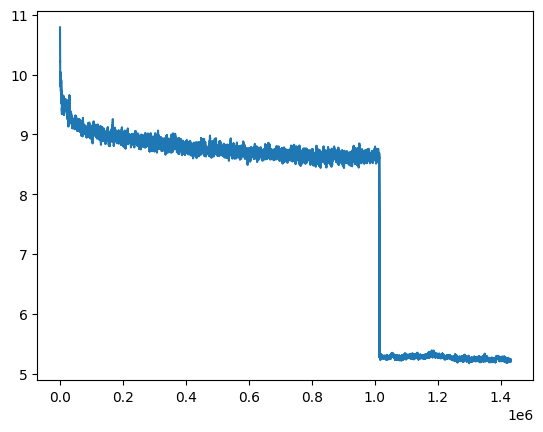

In [26]:
window_size = 1000
plt.plot([sum(losses[i:i+window_size])/window_size for i in range(len(losses) - window_size)])